In [1]:
import pandas as pd
import numpy as np
from PIL import Image

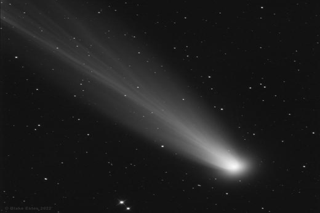

In [2]:
img = Image.open('images/comet.png').convert('L').resize((640 // 2,426 // 2))
img

In [3]:
imgMat = np.array(img)
imgMat

array([[ 46,  52,  51, ...,  18,  18,  18],
       [ 43,  58,  49, ...,  18,  18,  18],
       [ 49, 103,  69, ...,  18,  18,  18],
       ...,
       [ 22,  37,  29, ...,  19,  19,  19],
       [ 18,  21,  18, ...,  19,  19,  19],
       [ 20,  23,  19, ...,  19,  19,  19]], shape=(213, 320), dtype=uint8)

In [4]:
lap_kernel = np.array([[0,1,0],[1,-4,1],[0,1,0]]) 

In [5]:
lapMat = imgMat.copy() 
for i in range(1,len(imgMat) - 1): #iterate over rows, skipping borders
    for j in range(1,len(imgMat[0]) - 1): #iterate over columns, skipping borders
        value = lap_kernel * imgMat[(i - 1):(i + 2), (j - 1):(j + 2)] #element-wise multiplication, selects exactly 3 rows: i - 1, i, and i + 1(syntax= start:stop, stops at stop-1)
        lapMat[i][j] = min(max(0,value.sum()),255) #summation of the 9 values, clip to [0,255]
        # if value.sum() < 0:
        #     lapMat[i][j] = 0
        # elif value.sum() > 255:
        #     lapMat[i][j] = 255
        # else:
        #     lapMat[i][j] = value.sum()

In [ ]:
fin = Image.fromarray(lapMat)
#image after summation and clipping with the kernel

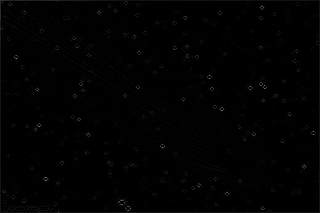

In [7]:
fin

In [8]:
fin.save('images/lap1.jpeg')

In [9]:
# performs image sharpening
lapMat = imgMat.copy()
for i in range(1,len(imgMat) - 1):
    for j in range(1,len(imgMat[0]) - 1):
        value = lap_kernel * imgMat[(i - 1):(i + 2), (j - 1):(j + 2)]
        lapMat[i][j] = min(max(0,imgMat[i][j] -  value.sum()),255) #sharpening by subtracting the laplacian from the original image, clip to [0,255]
        # if imgMat[i][j] - value.sum() < 0:
        #     lapMat[i][j] = 0
        # elif imgMat[i][j] - value.sum() > 255:
        #     lapMat[i][j] = 255
        # else:
        #     lapMat[i][j] = imgMat[i][j] - value.sum() ,, if positive center add ,if negative subtract

In [10]:
fin = Image.fromarray(lapMat)

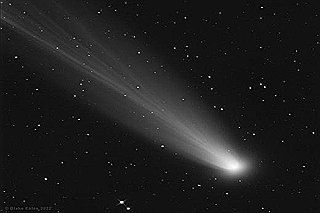

In [11]:
fin

In [12]:
fin.save('images/lap2.jpeg')